Project Title & Problem Statement

In [ ]:
# Customer Churn Prediction using Random Forest and SHAP Explainability

# Objective:
# Predict whether a customer will churn and explain the model's decisions using SHAP.

Install Libraries

In [7]:
!pip install shap

Import Libraries

In [8]:
import pandas as pd
import numpy as np

import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Images Folder

In [58]:
import os

os.makedirs("images", exist_ok=True)

Load Dataset

In [9]:
df = pd.read_csv("/content/archive (1).zip")

Dataset Exploration

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.shape

(7043, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Data Cleaning

In [14]:
# remove customer-id

df.drop("customerID", axis=1, inplace=True)

In [15]:
# convert total charges

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [16]:
# fill missing vals

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

/tmp/ipykernel_930/2189125351.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(


Exploratory Data Analysis (EDA)

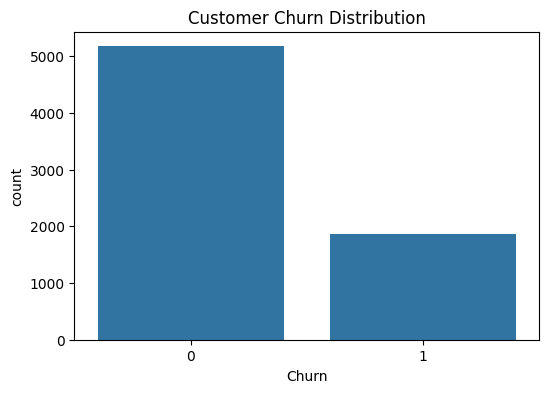

In [59]:
# Churn Distribution

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

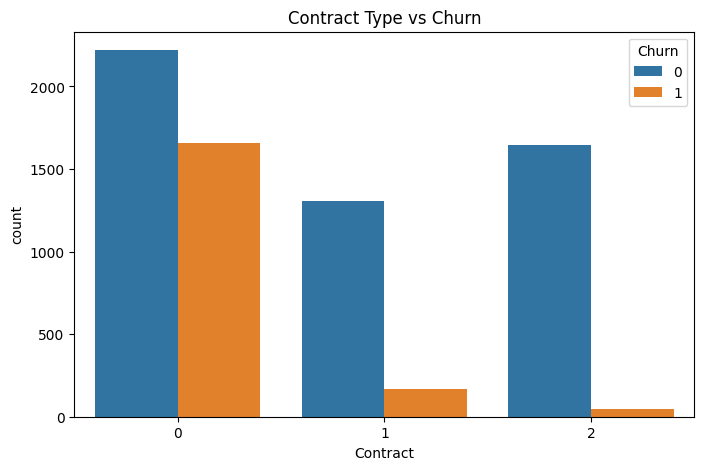

In [60]:
# Contract Type vs Churn

plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()

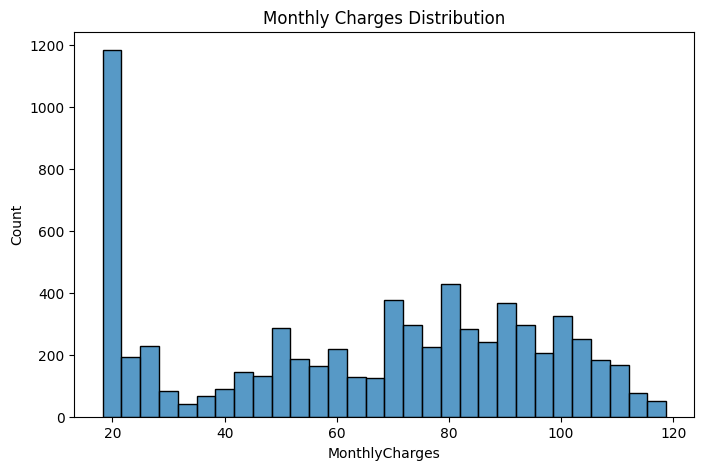

In [61]:
# Monthly Charges Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title('Monthly Charges Distribution')
plt.show()

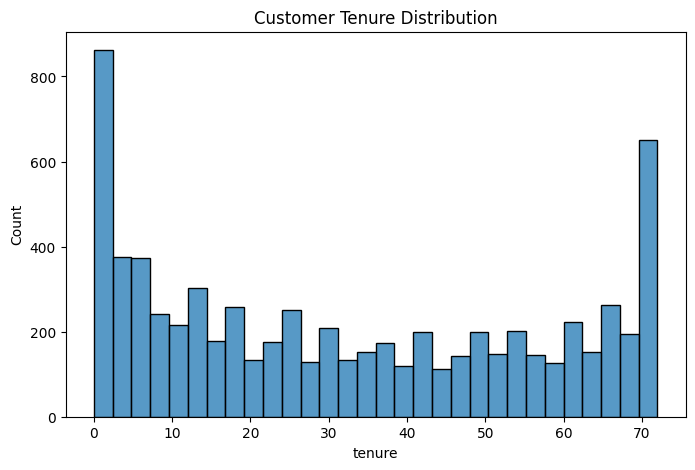

In [62]:
# Tenure Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30)
plt.title('Customer Tenure Distribution')
plt.show()

Data Preprocessing

In [17]:
# encode categorical columns

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

Feature Selection

In [18]:
# split features and target

X = df.drop("Churn", axis=1)

y = df["Churn"]

Train-Test Split

In [19]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest Model

In [20]:
# train random forest

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predictions

In [21]:
# predictions

y_pred = model.predict(X_test)

Model Evaluation

In [22]:
# accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.7955997161107168


In [23]:
# classification report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [24]:
# confusion matrix (Raw Output)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[945  91]
 [197 176]]


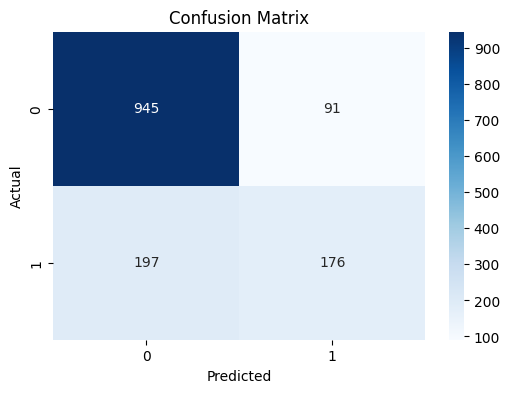

In [63]:
# Confusion Matrix Heatmap (Image)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    "images/confusion_matrix.png",
    bbox_inches='tight'
)

plt.show()

In [65]:
# Feature Importance Analysis

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
18,TotalCharges,0.189992
17,MonthlyCharges,0.177867
4,tenure,0.157428
14,Contract,0.077357
16,PaymentMethod,0.050379
8,OnlineSecurity,0.047432
11,TechSupport,0.044190
0,gender,0.028117
9,OnlineBackup,0.027067
7,InternetService,0.026444


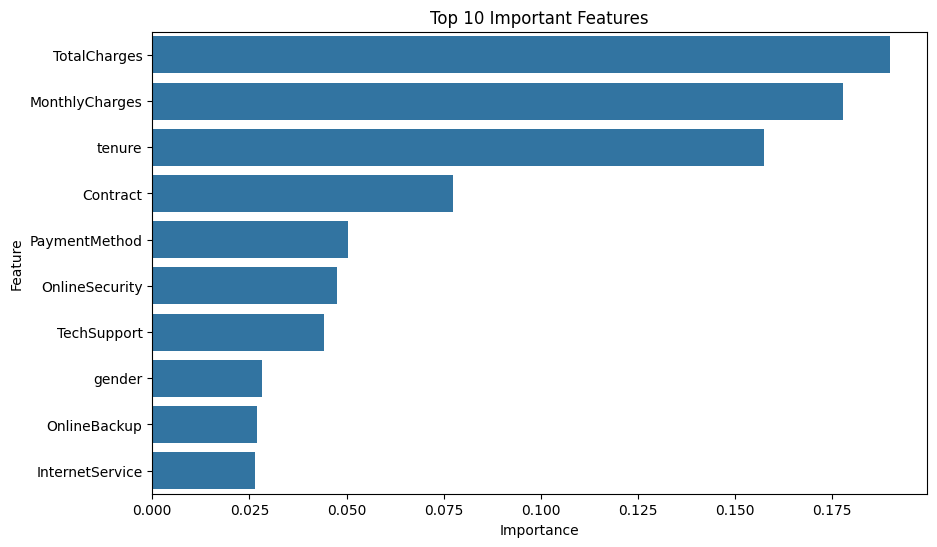

In [66]:
# Feature Importance Plot (Image)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')

plt.savefig(
    "images/feature_importance.png",
    bbox_inches='tight'
)

plt.show()

SHAP Explainability

In [25]:
# Create SHAP Explainer

explainer = shap.TreeExplainer(model)

In [27]:
# shap values

shap_values = explainer.shap_values(X_test)

In [39]:
# debug

print(type(shap_values))
print(explainer.expected_value)
print(shap_values.shape)
len(shap_values)

<class 'numpy.ndarray'>
[0.73468584 0.26531416]
(1409, 19, 2)


1409

Check SHAP Version

In [40]:
import shap
print(shap.__version__)

0.51.0


Global Explainability

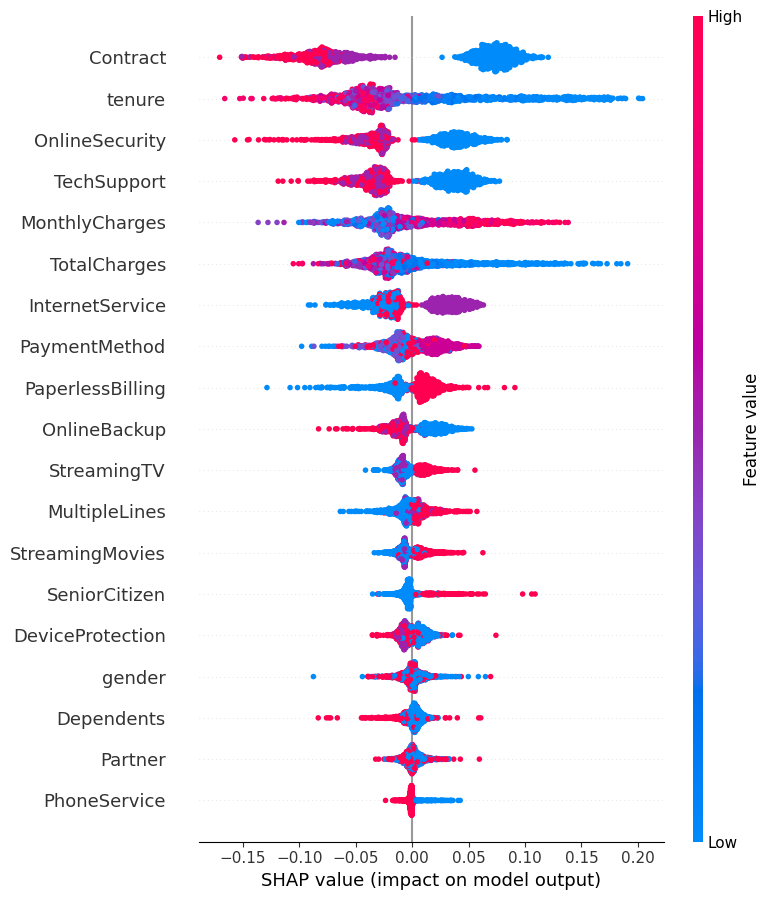

In [41]:
# SHAP Beeswarm Plot

shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)


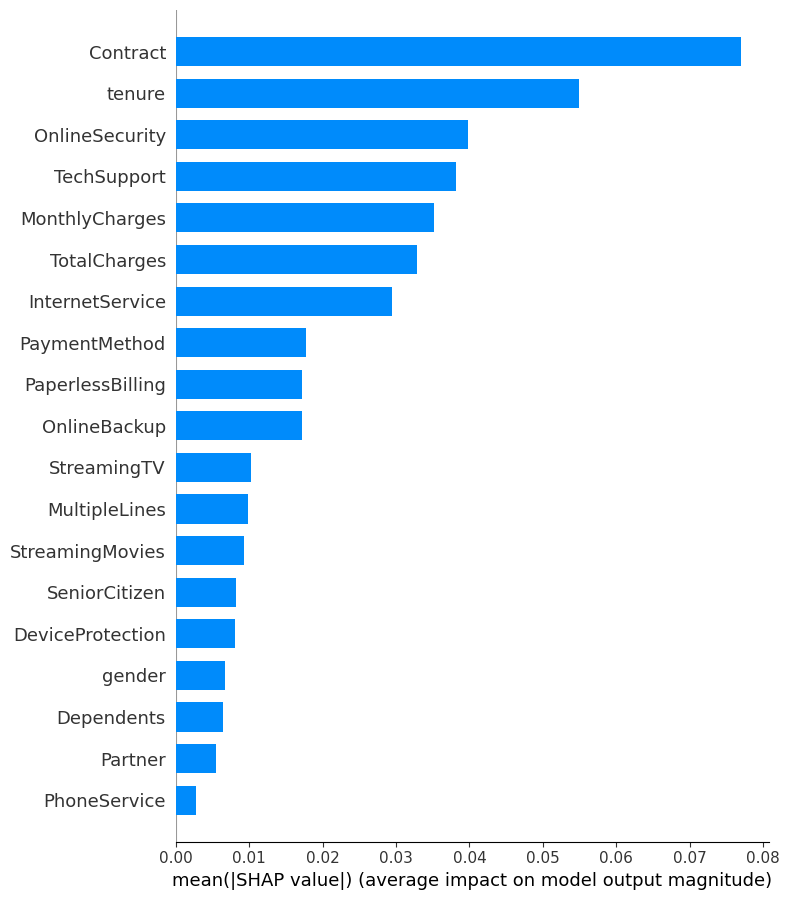

In [43]:
# SHAP Bar Plot

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="bar"
)

Local Explainability

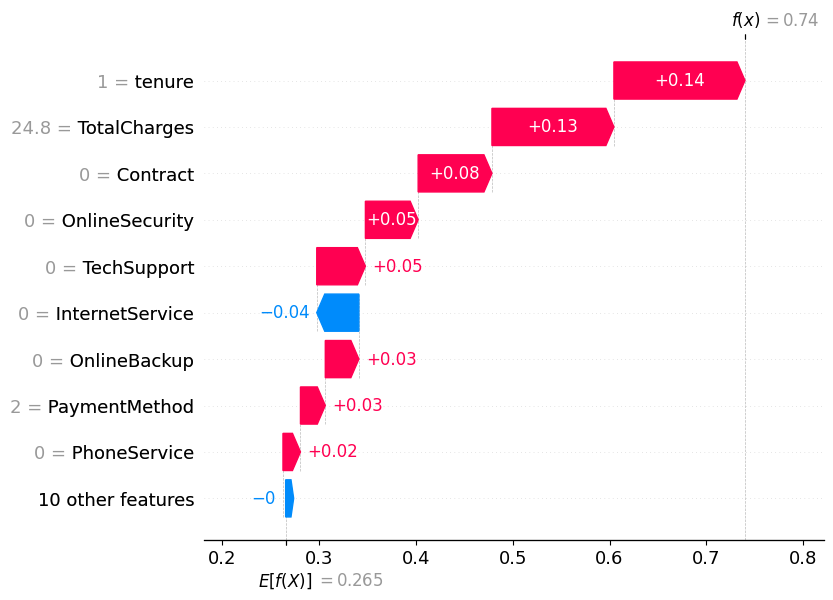

In [44]:
# SHAP Waterfall Plot
# Waterfall Plot for One Customer

sample_idx = 0

exp = shap.Explanation(
    values=shap_values[sample_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[sample_idx].values,
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(exp)

Model Comparison

In [51]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

In [52]:
# train logistic regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
# accuracy

from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8161816891412349


In [54]:
# compare models

print("Random Forest Accuracy:", accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

Random Forest Accuracy: 0.7955997161107168
Logistic Regression Accuracy: 0.8161816891412349


In [57]:
# Business Insights

# 1. Contract type significantly influences churn.

# 2. Customers with shorter tenure show higher churn tendency.

# 3. Monthly charges impact customer retention.

# 4. SHAP analysis provides transparent explanations for individual predictions.

# 5. Explainability can help businesses identify at-risk customers.

Conclusion

In [ ]:
# The Random Forest model achieved approximately 80% accuracy.

# SHAP explainability was used to understand both global and local prediction behavior.

# The project demonstrates how machine learning and explainable AI can be combined to support business decision-making.